In [6]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Conv2D, UpSampling2D
from tensorflow.keras.models import Model

In [9]:
import os

# Define explicit paths to the subfolders
train_folder = os.path.join("flood_dataset", "train")
test_folder = os.path.join("flood_dataset", "test")

# Gather filenames from both directories
train_files = [f for f in os.listdir(train_folder) if f.endswith((".png", ".jpg", ".jpeg"))]
test_files = [f for f in os.listdir(test_folder) if f.endswith((".png", ".jpg", ".jpeg"))]

print(f"Found {len(train_files)} images for training.")
print(f"Found {len(test_files)} images for testing.")

Found 40 images for training.
Found 12 images for testing.


In [10]:
def create_mask(img):

    colors = np.array([
        [0,255,0],      # class 0
        [100,255,100],  # class 1
        [0,255,255],    # class 2
        [0,0,255],      # class 3
        [0,0,139]       # class 4
    ])

    img_flat = img.reshape(-1,3)

    distances = np.linalg.norm(img_flat[:,None] - colors, axis=2)

    mask = np.argmin(distances, axis=1)

    return mask.reshape(img.shape[0], img.shape[1])

In [11]:
def load_data_from_dir(folder_path, file_list):
    loaded_images = []
    loaded_masks = []
    
    for filename in file_list:
        img_path = os.path.join(folder_path, filename)
        
        # Read and preprocess the color image
        img = cv2.imread(img_path)
        img = cv2.resize(img, (256, 256))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Pass the color image to create the numerical 0-4 targets
        mask = create_mask(img)
        
        loaded_images.append(img)
        loaded_masks.append(mask)
        
    # Normalize images to [0, 1] and keep masks as integers
    return np.array(loaded_images) / 255.0, np.array(loaded_masks)

# Load train and test sets cleanly from their respective folders
X_train, y_train = load_data_from_dir(train_folder, train_files)
X_test, y_test = load_data_from_dir(test_folder, test_files)

print("X_train shape:", X_train.shape, "| y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape, "| y_test shape:", y_test.shape)

X_train shape: (40, 256, 256, 3) | y_train shape: (40, 256, 256)
X_test shape: (12, 256, 256, 3) | y_test shape: (12, 256, 256)


In [5]:
X_train = images[:8]
y_train = masks[:8]

X_test = images[8:]
y_test = masks[8:]

In [12]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(256,256,3)
)



for layer in base_model.layers:
    layer.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 23s 0us/step


In [13]:
x = base_model.output

x = tf.keras.layers.UpSampling2D((2,2))(x)
x = Conv2D(256,(3,3),padding='same',activation='relu')(x)

x = tf.keras.layers.UpSampling2D((2,2))(x)
x = Conv2D(128,(3,3),padding='same',activation='relu')(x)

x = tf.keras.layers.UpSampling2D((2,2))(x)
x = Conv2D(64,(3,3),padding='same',activation='relu')(x)

x = tf.keras.layers.UpSampling2D((2,2))(x)
x = Conv2D(32,(3,3),padding='same',activation='relu')(x)

x = tf.keras.layers.UpSampling2D((2,2))(x)   
x = Conv2D(16,(3,3),padding='same',activation='relu')(x)

outputs = Conv2D(5,(1,1),activation='softmax')(x)

In [14]:
model = Model(inputs=base_model.input, outputs=outputs)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 28,698,565 (109.48 MB)

 Trainable params: 5,110,853 (19.50 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [15]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [25]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=1
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - accuracy: 0.8200 - loss: 1.0332
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.9453 - loss: 0.3555
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.9453 - loss: 0.2841
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.9453 - loss: 0.2602
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.9453 - loss: 0.2424
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.9453 - loss: 0.2199
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.9453 - loss: 0.2133
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.9453 - loss: 0.2015
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.9453 - loss: 0.1974
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.9453 - loss: 0.1909
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.9453 - loss: 0.1813
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.9453 - loss: 0.177

In [26]:
prediction = model.predict(X_test)

pred_mask = np.argmax(prediction, axis=-1)[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 797ms/step


In [27]:
accuracy = np.sum(pred_mask == y_test[0]) / y_test[0].size

print("Pixel Accuracy:", accuracy)

Pixel Accuracy: 0.9731903076171875


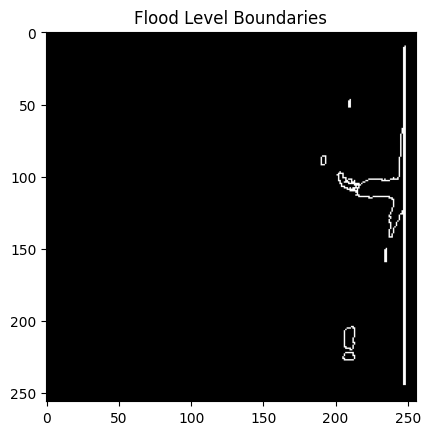

In [28]:
boundary = np.zeros_like(pred_mask)

boundary[:,:-1] |= (pred_mask[:,:-1] != pred_mask[:,1:])
boundary[:-1,:] |= (pred_mask[:-1,:] != pred_mask[1:,:])

boundary = boundary.astype(np.uint8)*255

plt.imshow(boundary,cmap='gray')
plt.title("Flood Level Boundaries")
plt.show()

In [30]:
print("Mask classes:", np.unique(masks))
print("Test mask classes:", np.unique(y_test[0]))
print("Predicted classes:", np.unique(pred_mask))

Mask classes: [0 1 2 3 4]
Test mask classes: [0 1 2 3 4]
Predicted classes: [1 2 3 4]


In [17]:
import tf2onnx

# Define the shape of the input the model expects (Batch Size, Height, Width, Channels)
input_signature = [tf.TensorSpec([None, 256, 256, 3], tf.float32, name='input_image')]

onnx_model_path = "resnet50_flood_model.onnx"

print("Converting model to ONNX...")
model_proto, _ = tf2onnx.convert.from_keras(
    model, 
    input_signature=input_signature, 
    output_path=onnx_model_path
)

print(f"Success! Model exported to {onnx_model_path}")

Converting model to ONNX...


Success! Model exported to resnet50_flood_model.onnx


--- Top 10 Colors in img0.jpg (Multicolored) ---
Color RGB: [255 255 255] | Count: 726843 pixels
Color RGB: [  2  32 228] | Count: 12123 pixels
Color RGB: [  0 242 243] | Count: 9384 pixels
Color RGB: [0 0 0] | Count: 3972 pixels
Color RGB: [251 255 250] | Count: 1972 pixels
Color RGB: [255 254 255] | Count: 1791 pixels
Color RGB: [254 255 255] | Count: 1705 pixels
Color RGB: [255 255 253] | Count: 1433 pixels
Color RGB: [241 255 239] | Count: 1342 pixels
Color RGB: [ 49 222 130] | Count: 1333 pixels

--- Top 10 Pixel Values in img1.jpg (Black & White) ---
Grayscale Value: 0 | Count: 812879 pixels
Grayscale Value: 255 | Count: 51084 pixels
Grayscale Value: 1 | Count: 7312 pixels
Grayscale Value: 254 | Count: 5862 pixels
Grayscale Value: 2 | Count: 4575 pixels
Grayscale Value: 253 | Count: 3579 pixels
Grayscale Value: 3 | Count: 2309 pixels
Grayscale Value: 252 | Count: 1752 pixels
Grayscale Value: 4 | Count: 882 pixels
Grayscale Value: 251 | Count: 691 pixels


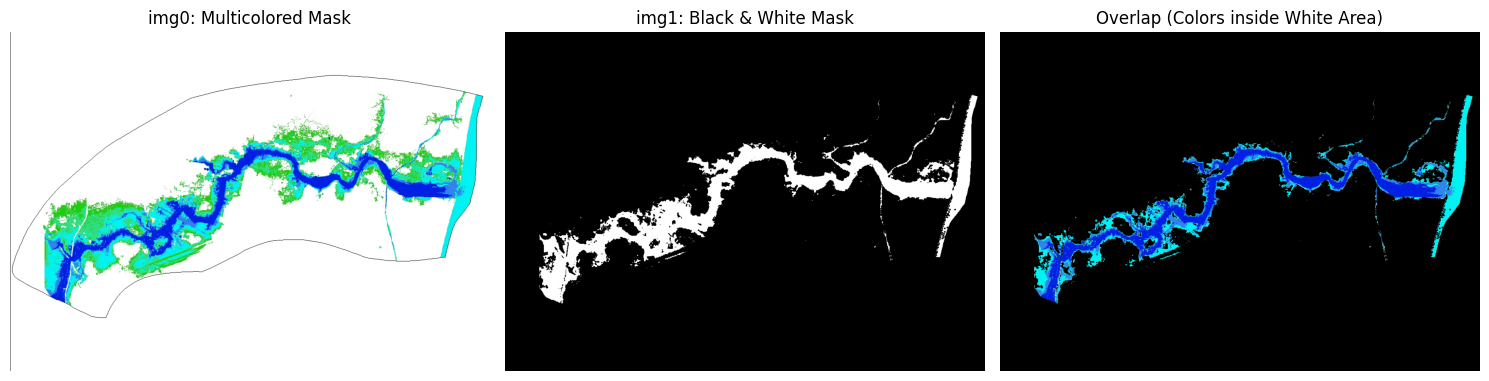

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the images
# img0: Multicolored (Convert BGR to RGB for correct matplotlib display)
img0 = cv2.imread('img0.jpg')
img0 = cv2.cvtColor(img0, cv2.COLOR_BGR2RGB)

# img1: Black & White (Load directly as Grayscale)
img1 = cv2.imread('img1.jpg', cv2.IMREAD_GRAYSCALE)

# 2. Count Unique Pixel Values in the Multicolored Image (img0)
pixels_0 = img0.reshape(-1, 3)
unique_colors_0, counts_0 = np.unique(pixels_0, axis=0, return_counts=True)
# Sort by most frequent to avoid JPEG noise
sorted_idx_0 = np.argsort(-counts_0)

print("--- Top 10 Colors in img0.jpg (Multicolored) ---")
for i in range(min(10, len(unique_colors_0))):
    color = unique_colors_0[sorted_idx_0[i]]
    count = counts_0[sorted_idx_0[i]]
    print(f"Color RGB: {color} | Count: {count} pixels")

# 3. Count Unique Pixel Values in the B&W Image (img1)
pixels_1 = img1.reshape(-1)
unique_colors_1, counts_1 = np.unique(pixels_1, return_counts=True)
sorted_idx_1 = np.argsort(-counts_1)

print("\n--- Top 10 Pixel Values in img1.jpg (Black & White) ---")
for i in range(min(10, len(unique_colors_1))):
    val = unique_colors_1[sorted_idx_1[i]]
    count = counts_1[sorted_idx_1[i]]
    print(f"Grayscale Value: {val} | Count: {count} pixels")

# 4. Create the Overlap
# First, ensure the B&W image is perfectly binary (0 or 255) to fix any JPG blur
_, binary_mask = cv2.threshold(img1, 127, 255, cv2.THRESH_BINARY)

# Use bitwise_and to extract colors from img0 ONLY where img1 is White (255)
overlap = cv2.bitwise_and(img0, img0, mask=binary_mask)

# 5. Plot the Results Side-by-Side
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("img0: Multicolored Mask")
plt.imshow(img0)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("img1: Black & White Mask")
plt.imshow(img1, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Overlap (Colors inside White Area)")
plt.imshow(overlap)
plt.axis('off')

plt.tight_layout()
plt.show()

--- Overlap Evaluation ---
Intersection over Union (IoU): 55.69%
Overall Pixel Matching Accuracy: 96.55%


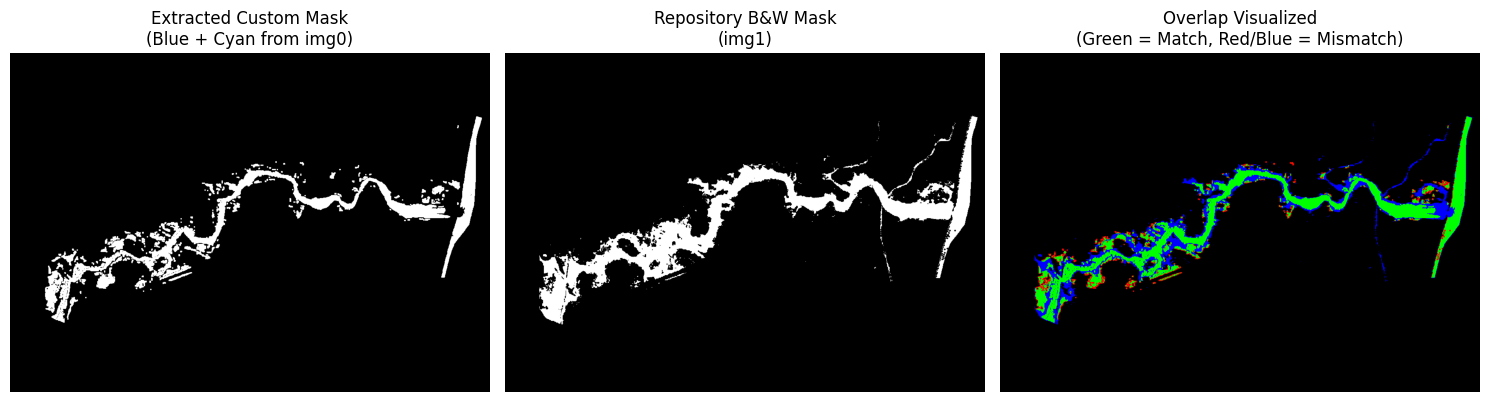

In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the images
img0 = cv2.imread('img0.jpg')
img0 = cv2.cvtColor(img0, cv2.COLOR_BGR2RGB) # Keep RGB format
img1 = cv2.imread('img1.jpg', cv2.IMREAD_GRAYSCALE)

# 2. Define the Color Ranges to account for JPEG compression noise
# Blue target: around [2, 32, 228]
lower_blue = np.array([0, 10, 180])
upper_blue = np.array([20, 60, 255])

# Cyan target: around [0, 242, 243]
lower_cyan = np.array([0, 200, 200])
upper_cyan = np.array([30, 255, 255])

# 3. Create masks for both colors and combine them
mask_blue = cv2.inRange(img0, lower_blue, upper_blue)
mask_cyan = cv2.inRange(img0, lower_cyan, upper_cyan)
custom_mask = cv2.bitwise_or(mask_blue, mask_cyan)

# Clean up minor isolated noise pixels using a morphological opening
kernel = np.ones((3,3), np.uint8)
custom_mask = cv2.morphologyEx(custom_mask, cv2.MORPH_OPEN, kernel)

# 4. Clean up the repo's B&W mask to make it perfectly binary (0 or 255)
_, repo_binary_mask = cv2.threshold(img1, 127, 255, cv2.THRESH_BINARY)

# 5. Calculate Overlap Metrics (Intersection over Union & Accuracy)
intersection = cv2.bitwise_and(custom_mask, repo_binary_mask)
union = cv2.bitwise_or(custom_mask, repo_binary_mask)

# Count non-zero pixels for metrics
num_intersection = np.count_nonzero(intersection)
num_union = np.count_nonzero(union)

iou = (num_intersection / num_union) * 100 if num_union > 0 else 0
accuracy = (np.sum(custom_mask == repo_binary_mask) / repo_binary_mask.size) * 100

print(f"--- Overlap Evaluation ---")
print(f"Intersection over Union (IoU): {iou:.2f}%")
print(f"Overall Pixel Matching Accuracy: {accuracy:.2f}%")

# 6. Plot the results to visually confirm
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Extracted Custom Mask\n(Blue + Cyan from img0)")
plt.imshow(custom_mask, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Repository B&W Mask\n(img1)")
plt.imshow(repo_binary_mask, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Overlap Visualized\n(Green = Match, Red/Blue = Mismatch)")
# Create an RGB image to show overlap precision
overlap_visualization = np.zeros((custom_mask.shape[0], custom_mask.shape[1], 3), dtype=np.uint8)
overlap_visualization[intersection > 0] = [0, 255, 0]  # Perfect matches in Green
overlap_visualization[(custom_mask > 0) & (repo_binary_mask == 0)] = [255, 0, 0] # Custom mask only (Red)
overlap_visualization[(repo_binary_mask > 0) & (custom_mask == 0)] = [0, 0, 255] # Repo mask only (Blue)

plt.imshow(overlap_visualization)
plt.axis('off')

plt.tight_layout()
plt.show()